<a href="https://colab.research.google.com/github/Sherzod19s/BUSI2045---Data-Analytics-for-Business-Decision-Making/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2
## SADIEV Sherzodbek 22200959

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [7]:
NILT2012GR = pd.read_csv('/content/NILT2012GR_assignment.csv')
NILT2012GR.head()

,rage,ragesq,persinc2,log_income
0,44,1936,22100,10.003333
1,86,7396,6760,8.818778
2,26,676,9880,9.198268
3,40,1600,27300,10.214642
4,44,1936,16120,9.687816


In [8]:
NILT2012GR.shape

(895, 4)

In [9]:
NILT2012GR.corr()

,rage,ragesq,persinc2,log_income
rage,1.000000,0.983619,-0.036106,0.004042
ragesq,0.983619,1.000000,-0.077204,-0.034876
persinc2,-0.036106,-0.077204,1.000000,0.832939
log_income,0.004042,-0.034876,0.832939,1.000000


Q1.
A

In [10]:
x = NILT2012GR['rage']
x = sm.add_constant(x)
x

,const,rage
0,1.0,44
1,1.0,86
2,1.0,26
3,1.0,40
4,1.0,44
...,...,...
890,1.0,38
891,1.0,23
892,1.0,45
893,1.0,49


In [11]:
y = NILT2012GR['log_income']

In [12]:
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.01459
Date:                Sun, 05 Apr 2026   Prob (F-statistic):              0.904
Time:                        05:12:37   Log-Likelihood:                -1148.0
No. Observations:                 895   AIC:                             2300.
Df Residuals:                     893   BIC:                             2309.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3769      0.084    111.385      0.0

Q1.
B

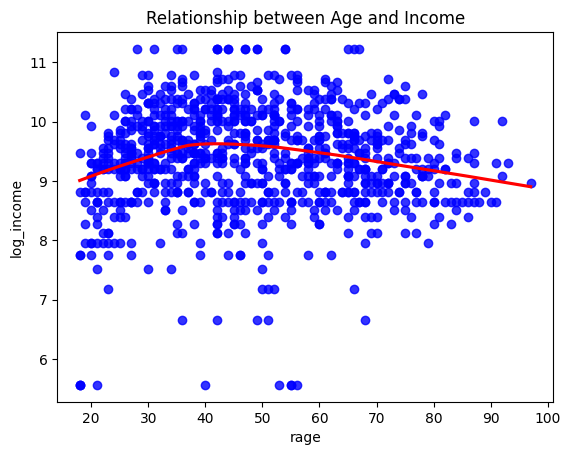

In [13]:
sns.regplot(data=NILT2012GR, x='rage', y='log_income',scatter_kws={'color': 'blue'}, line_kws={'color': 'red'},lowess=True)
plt.title('Relationship between Age and Income')
plt.show()

Q1.
C

In [14]:
X = NILT2012GR[['rage', 'ragesq']]
X = sm.add_constant(X)

In [15]:
model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     21.74
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           6.07e-10
Time:                        05:12:40   Log-Likelihood:                -1126.7
No. Observations:                 895   AIC:                             2259.
Df Residuals:                     892   BIC:                             2274.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0929      0.211     38.277      0.0


The quadratic regression shows that both age (β = 0.0576, p < 0.001) and age-squared (β = -0.0006, p < 0.001) are highly statistically significant. Together they explain 4.6% of income variation (R² = 0.046) and jointly predict income with F = 21.74 (p < 0.001). The positive linear and negative quadratic coefficients confirm an inverted-U relationship: income rises until approximately age 48, then declines. This aligns with the life-cycle hypothesis of earnings. However, severe multicollinearity (condition number ≈ 24,000) between age and its square suggests centered variables would improve numerical stability.

Q1.D

The linear model in part (a) fails because it cannot capture the inverted-U relationship visible in the scatterplot — where income rises to mid-life then declines. By forcing a single slope, the positive and negative phases cancel out, yielding an insignificant coefficient. The quadratic model in part (c) explicitly models this curvature through the age-squared term, allowing both the initial rise (significant positive linear coefficient) and subsequent decline (significant negative quadratic coefficient) to be detected. This demonstrates how functional form misspecification can obscure true relationships: the effect of age exists but is non-linear, requiring a polynomial specification to reveal its statistical significance

In [43]:
hk_visitors = pd.read_csv('hk_visitors.csv')
hk_visitors

,ID,Age,Origin,Spending,Purpose
0,1,56,Chinese Mainland,358.57,Leisure
1,2,69,Chinese Mainland,376.08,Leisure
2,3,46,Japan,402.78,Leisure
3,4,32,Australia,198.09,Leisure
4,5,60,Australia,435.62,Business
...,...,...,...,...,...
245,246,43,Australia,286.37,Leisure
246,247,49,Germany,349.56,Leisure
247,248,23,Australia,253.92,Business
248,249,49,Japan,318.26,Leisure


Q2.
A

In [44]:
origin_count = pd.DataFrame(hk_visitors['Origin'].value_counts())
origin_count

,count
Origin,
Chinese Mainland,103
Australia,44
Japan,27
UK,26
Canada,26
Germany,24


In [45]:
origin_count['count']

,count
Origin,
Chinese Mainland,103
Australia,44
Japan,27
UK,26
Canada,26
Germany,24


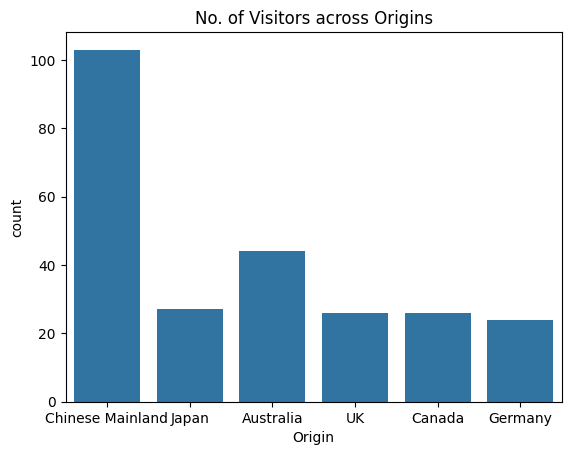

In [19]:
custom_order = ['Chinese Mainland','Japan', 'Australia', 'UK', 'Canada', 'Germany']
sns.barplot(x=origin_count.index, y=origin_count['count'], order=custom_order)
plt.title('No. of Visitors across Origins')
plt.xlabel('Origin')
plt.ylabel('count')
plt.show()

Q2.
B

In [46]:
from scipy.stats import chisquare
chi2_stat, p_value = chisquare(origin_count['count'])
print('Chi-squared Statistic: ', chi2_stat)
print('P-value: ', p_value)

Chi-squared Statistic:  114.84800000000001
P-value:  3.866979308335925e-23


To test whether the number of visitors from each origin is the same in the population, a chi-square goodness-of-fit test was conducted.

The null hypothesis states that the population proportions are equal across all origin categories, while the alternative hypothesis states that the proportions are not all equal.

The test produced a chi-square statistic of
114.848 with a p-value of
3.866979308335925e-23.


Since the p-value is far below 0.05, the null hypothesis is rejected. Therefore, there is sufficient statistical evidence to conclude that the number of visitors from each origin is not the same in the population.

Q2.C

In [20]:
pd.crosstab(hk_visitors['Origin'], hk_visitors['Purpose'], normalize='index')

Purpose,Business,Leisure
Origin,,
Australia,0.409091,0.590909
Canada,0.346154,0.653846
Chinese Mainland,0.349515,0.650485
Germany,0.333333,0.666667
Japan,0.481481,0.518519
UK,0.384615,0.615385


Q2.D

In [47]:
two_way_percent = pd.crosstab(hk_visitors['Origin'], hk_visitors['Purpose'], normalize='index')
two_way_percent.reset_index(inplace=True)
two_way_percent = two_way_percent.melt(id_vars='Origin', value_name='Proportion')
two_way_percent

,Origin,Purpose,Proportion
0,Australia,Business,0.409091
1,Canada,Business,0.346154
2,Chinese Mainland,Business,0.349515
3,Germany,Business,0.333333
4,Japan,Business,0.481481
5,UK,Business,0.384615
6,Australia,Leisure,0.590909
7,Canada,Leisure,0.653846
8,Chinese Mainland,Leisure,0.650485
9,Germany,Leisure,0.666667


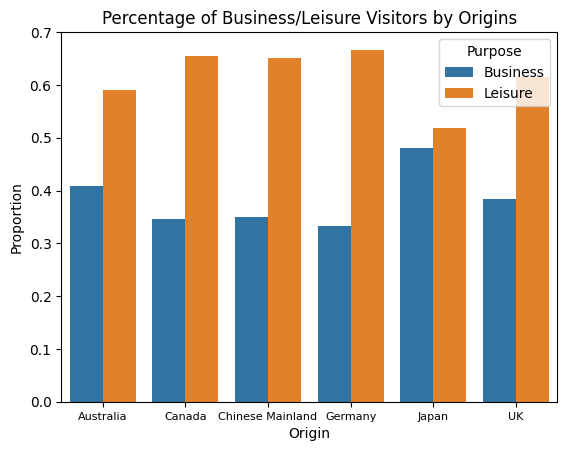

In [48]:
sns.barplot(data=two_way_percent, x='Origin', y='Proportion', hue='Purpose')
plt.title('Percentage of Business/Leisure Visitors by Origins')
plt.xticks(fontsize=8)
plt.ylabel('Proportion')
plt.show()

Q2.E


In [56]:
hk_visitors['Purpose'].value_counts().reset_index()

,Purpose,count
0,Leisure,156
1,Business,94


In [71]:
# 1. Create a frequency table for the number of visitors by purpose
purpose_counts = hk_visitors['Purpose'].value_counts()
print("Frequency Table for Visitor Purpose:")
print(purpose_counts)

Frequency Table for Visitor Purpose:
Purpose
Leisure     156
Business     94
Name: count, dtype: int64


In [70]:
from statsmodels.stats.proportion import proportions_ztest
num_business_visitors = purpose_counts['Business']
total_visitors = len(hk_visitors)
z_stat, p_value = proportions_ztest(count=num_business_visitors, nobs=total_visitors, value=0.40)
print(f"\nZ-statistic: {z_stat:}")
print(f"P-value: {p_value:}")



Z-statistic: -0.7834206750995835
P-value: 0.43338011899010787


Null Hypothesis (H0): The true percentage of business visitors in the population is 40% (p = 0.40).

Alternative Hypothesis (H1): The true percentage of business visitors in the population is not 40% (p ≠ 0.40).

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is not enough evidence to conclude that the true percentage of business visitors in the population is different from 40%

Q2.F

In [49]:
average_spending = pd.DataFrame(hk_visitors.groupby('Purpose')['Spending'].mean().reset_index())
average_spending

,Purpose,Spending
0,Business,306.395957
1,Leisure,325.614872


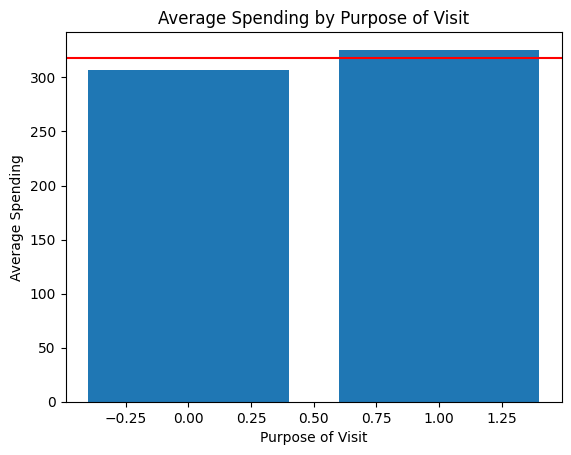

In [50]:
plt.bar(average_spending.index, average_spending.Spending)
plt.axhline(y=hk_visitors['Spending'].mean(), color='red')
plt.title('Average Spending by Purpose of Visit')
plt.xlabel('Purpose of Visit')
plt.ylabel('Average Spending')
plt.show()

Q2.G

In [25]:
hk_visitors.groupby('Purpose')['Spending'].mean().reset_index()

,Purpose,Spending
0,Business,306.395957
1,Leisure,325.614872


In [52]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(hk_visitors[hk_visitors['Purpose']=='Business']['Spending'],
                                hk_visitors[hk_visitors['Purpose']=='Leisure']['Spending'])
print("t_statistic: ",t_stat)
print("p-value: ",p_val)

t_statistic:  -1.166901405772921
p-value:  0.24437098988039777


There is no statistically significant difference in spending between business and leisure visitors (t = -1.17, p = 0.244). In fact, leisure visitors spend slightly more on average, though this difference is not statistically distinguishable from zero at conventional significance levels.

Q2.H

In [27]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [37]:
model = ols('Age ~ Origin', data=hk_visitors).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

             df        sum_sq     mean_sq         F    PR(>F)
Origin      5.0   1472.967457  294.593491  1.210795  0.304598
Residual  244.0  59366.632543  243.305871       NaN       NaN


To test whether visitor origin is associated with age in the population, I used a one-way ANOVA because Age is a quantitative variable and Origin is a categorical variable.

The null hypothesis is that the population mean age is the same for all origin groups, while the alternative hypothesis is that at least one origin group has a different mean age.

### The ANOVA results gave F=1.2108 and p=0.3046.

Since the p-value is greater than 0.05, I fail to reject the null hypothesis. Therefore, there is not enough statistical evidence to conclude that visitor origin is associated with age in the population.